In [1]:
import triton
import torch
import numpy as np
import os
import pandas as pd
from torch import nn, Tensor, autograd

from triton_gated_mlp.gated_mlp import FusedGatedMLP, EagerGatedMLP
from triton_gated_mlp.utils import get_device

from triton_gated_mlp.ops.fwd_block import mlp_hidden_states_fwd
# from triton_gated_mlp.ops.fwd_block import mlp_hidden_states_fwd as mlp_hidden_states_fwd_2
# from triton_gated_mlp.ops.fwd_tensor_desc import mlp_hidden_states_fwd as mlp_hidden_states_fwd_tensor_desc

In [ ]:
os.environ["TRITON_PRINT_AUTOTUNING"] = "1"

DTYPE = torch.float32

In [3]:
class GatedMLP(nn.Module):
    def __init__(
        self,
        hidden_size: int = 256,
        intermediate_size: int = 512,
        bias: bool = False,
        hidden_act: str = "silu",
        dropout_p: float = 0.0,
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.intermediate_size = intermediate_size
        self.gate_proj = nn.Linear(self.hidden_size, self.intermediate_size, bias=bias)
        self.up_proj = nn.Linear(self.hidden_size, self.intermediate_size, bias=bias)
        # self.down_proj = nn.Linear(self.intermediate_size, self.hidden_size, bias=bias)
        self.act = nn.Identity() #nn.SiLU()
        self.act_fn = hidden_act
        self.dropout = nn.Dropout(dropout_p)
        self.act_functional = torch.nn.functional.silu
        self.dropout_functional = torch.nn.functional.dropout
        self.dropout_p = dropout_p

    def forward(self, x, provider = "torch"):
        shapes = x.shape
        if len(shapes) > 2:
            x = x.view(-1, shapes[-1])
        match provider:
            # case "torch":
            #     hidden_states = self.dropout(self.act(self.gate_proj(x)) * self.up_proj(x))
            #     # down_proj = self.down_proj(hidden_states)
            #     return hidden_states
            # case "torch_functional":
            #     act = torch.nn.functional.silu
            #     xp = (x @ self.up_proj.weight.data.T) * act(x @ self.gate_proj.weight.data.T)
            #     xp = self.dropout(xp)
                # return xp 
            case "torch":
                x_up = self.up_proj(x)
                x_gp = self.gate_proj(x)
                x_act = self.act(x_gp)
                x_prod = x_up * x_act
                x_drop = self.dropout(x_prod)
                # down_proj = self.down_proj(hidden_states)
                return x_drop
            case "torch_functional":
                # xp = (x @ self.up_proj.weight.data.T) * self.act_functional(x @ self.gate_proj.weight.data.T)
                # xp = self.dropout(xp)
                x_up = x @ self.up_proj.weight.data.T + self.up_proj.bias.data
                x_gp = x @ self.gate_proj.weight.data.T + self.gate_proj.bias.data
                x_act = self.act_functional(x_gp)
                x_prod = x_up * x_act
                x_drop = self.dropout_functional(x_prod, p=self.dropout_p)
                return x_drop 
            case 'triton':
                return mlp_hidden_states_fwd(
                    x=x, 
                    Wu=self.up_proj.weight.data,
                    Wg=self.gate_proj.weight.data,
                    bu=self.up_proj.bias.data,
                    bg=self.gate_proj.bias.data,
                    act_fn='silu',
                    dropout_p=self.dropout.p,
                )
            # case 'triton_2':
            #     return mlp_hidden_states_fwd_2(
            #         x=x, 
            #         Wu=self.up_proj.weight.data,
            #         Wg=self.gate_proj.weight.data,
            #         act_fn='silu',
            #     )
            
            # case "triton_tensor_desc":
            #     return mlp_hidden_states_fwd_tensor_desc(
            #         x=x, 
            #         WT_up=self.up_proj.weight.data,
            #         WT_gp=self.gate_proj.weight.data,
            #         act_fn='silu',
            #     )
'''
    x: Tensor,
    WT_up: Tensor,  # this one is transposed
    WT_gp: Tensor,  # this one is transposed
    act_fn: str,
    WT_op: Tensor,  # this one is transposed
    b_gp: Tensor | None = None,
    b_op: Tensor | None = None,
    b_up: Tensor | None = None,
    dropout_p: float = 0.0,
'''

'\n    x: Tensor,\n    WT_up: Tensor,  # this one is transposed\n    WT_gp: Tensor,  # this one is transposed\n    act_fn: str,\n    WT_op: Tensor,  # this one is transposed\n    b_gp: Tensor | None = None,\n    b_op: Tensor | None = None,\n    b_up: Tensor | None = None,\n    dropout_p: float = 0.0,\n'

provider='torch', DTYPE=torch.float16, M=64, N=64, K=64
provider='torch_functional', DTYPE=torch.float16, M=64, N=64, K=64
provider='triton', DTYPE=torch.float16, M=64, N=64, K=64
Autotuning kernel _fwd_kernel with config BLOCK_SIZE_M: 16, BLOCK_SIZE_N: 16, BLOCK_SIZE_K: 16, GROUP_SIZE_M: 2, num_warps: 4, num_ctas: 1, num_stages: 3, maxnreg: None
Autotuning kernel _fwd_kernel with config BLOCK_SIZE_M: 16, BLOCK_SIZE_N: 16, BLOCK_SIZE_K: 16, GROUP_SIZE_M: 4, num_warps: 4, num_ctas: 1, num_stages: 3, maxnreg: None
Autotuning kernel _fwd_kernel with config BLOCK_SIZE_M: 16, BLOCK_SIZE_N: 16, BLOCK_SIZE_K: 16, GROUP_SIZE_M: 8, num_warps: 4, num_ctas: 1, num_stages: 3, maxnreg: None
Autotuning kernel _fwd_kernel with config BLOCK_SIZE_M: 16, BLOCK_SIZE_N: 16, BLOCK_SIZE_K: 16, GROUP_SIZE_M: 16, num_warps: 4, num_ctas: 1, num_stages: 3, maxnreg: None
Autotuning kernel _fwd_kernel with config BLOCK_SIZE_M: 16, BLOCK_SIZE_N: 16, BLOCK_SIZE_K: 16, GROUP_SIZE_M: 32, num_warps: 4, num_ctas: 1, nu

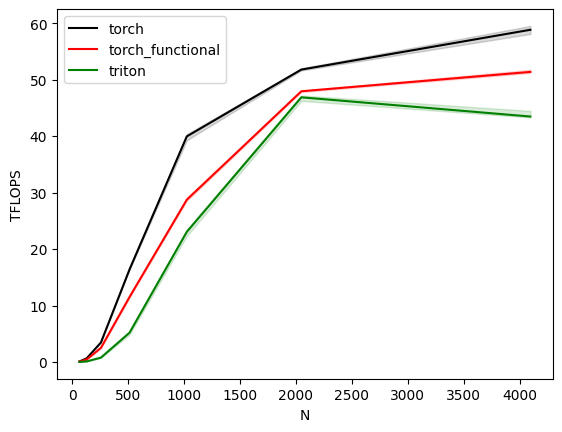

gated-mlp-performance:
        N       M       K      torch  torch_functional     triton
0    64.0    64.0    64.0   0.093091          0.060235   0.012043
1   128.0   128.0   128.0   0.633198          0.431158   0.097090
2   256.0   256.0   256.0   3.449263          2.496610   0.772716
3   512.0   512.0   512.0  16.384000         11.514905   5.190970
4  1024.0  1024.0  1024.0  39.945753         28.728108  23.045626
5  2048.0  2048.0  2048.0  51.774040         47.934905  46.863733
6  4096.0  4096.0  4096.0  58.824086         51.365374  43.464729


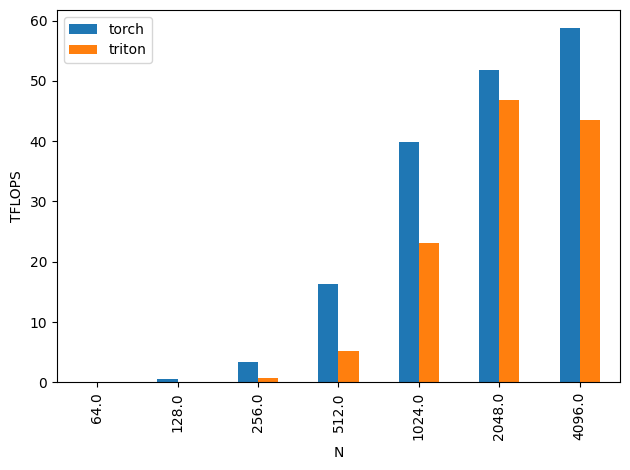

In [4]:
providers = ["torch", 'torch_functional', "triton"]

available_colors = [
    "black",
    "red",
    "green",
    "blue",
    "yellow",
    "cyan",
    "purple",
    "grey",
]
colors = available_colors[: len(providers)]

configs = []
configs.append(
    triton.testing.Benchmark(
        x_names=["N", "M", "K"],  # Argument names to use as an x-axis for the plot
        x_vals=[
            int(2**i) for i in np.arange(6, 13, 1)
        ],  # Different possible values for `x_name`
        line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
        # Possible values for `line_arg`
        # Don't compare to cublas for fp8 cases as torch.matmul doesn't support fp8 at the moment.
        line_vals=providers,  # ["triton"] if fp8_inputs else [ref_lib.lower(), "triton"],  # Label name for the lines
        line_names=providers,  # ["Triton"] if fp8_inputs else [ref_lib, "Triton"],  # Line styles
        styles=[
            (x, "-") for x, _ in zip(colors, providers)
        ],  # ("green", "-"), ("blue", "-")],
        ylabel="TFLOPS",  # Label name for the y-axis
        plot_name="gated-mlp-performance",  # Name for the plot, used also as a file name for saving the plot.
        args={},
    )
)

def step(mlp, x, provider):
    out = mlp(x, provider)
    # params = (x, mlp.gate_proj.weight, mlp.up_proj.weight, mlp.down_proj.weight)
    # grads = autograd.grad(out, params, torch.rand_like(x).to(x.device))


DEVICE = get_device()

def get_mlp(N, K, DEVICE, DTYPE):
    gmlp_kwargs = {
        "hidden_size": K,
        "intermediate_size": N,
        "dropout_p": 0.,
        "bias": True,
    }
    return GatedMLP(**gmlp_kwargs).to(DEVICE).to(DTYPE)

@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider):

    # M *= 4
    # K *= 2

    gmlp = get_mlp(N, K, DEVICE, DTYPE)
    print(f"{provider=}, {DTYPE=}, {M=}, {N=}, {K=}")

    x = torch.randn((M, K), device=DEVICE, dtype=DTYPE)
    x.requires_grad = True

    quantiles = [0.5, 0.2, 0.8]
    ms, min_ms, max_ms = triton.testing.do_bench(
        lambda: step(gmlp, x, provider), quantiles=quantiles
    )
    perf = lambda ms: 4 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)

df_ops: pd.DataFrame = benchmark.run(
    show_plots=True, print_data=True, return_df=True
)[0]
ax = df_ops.plot(x="N", kind="bar", y=["torch", "triton"], ylabel="TFLOPS")
ax.figure.tight_layout()
ax.figure.savefig("benchmark_tflops.png")